### Imports

In [2]:
import altitude_helper
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)
from altitude_helper import *

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

In [3]:
spherical_project_lat_lon

<function altitude_helper.spherical_project_lat_lon(az_arr, el_arr, lat_camera, lon_camera, h)>

### Load Data

In [4]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 10 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/ssl/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Interpolation Functions

In [4]:
# # do on r, g, b channels independently
# # interpolate to 1 line varying lat, single lon

# def line_interpolate(lat_proj, lon_proj, rgb, 
#                      lat_min, lat_max, lon_min, lon_max,
#                      lat_min_box, lat_max_box, 
#                      lon_min_box, lon_max_box,
#                      site_name, folder_name, time_index, 
#                      altitude):

#     """
#     input:
#         lat_proj = 2D projected latitude arr (output of project_lat_lon())
#         lon_proj = 2D projected longitude arr (output of project_lat_lon())
#         rgb = 3D rgb array (output of plot_lat_lon()) 
#         lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
#         lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
#         lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
#         lon_max = maximum longitude to create grid for (should be common between the 2 cameras)
#         lat_min_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
#         lat_max_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) --> change for diff altitude projs if necessary
#         lon_min_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
#         lon_max_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
#         time_index = for naming purposes 

#     output:
#         R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
#     """

#     # latitude and longitude arrays to define the interpolation grid
#     lat_arr = np.arange(lat_min, lat_max, 0.5) # this is about close to the actual pixel resolution
#     lon_arr = np.arange(lon_min, lon_max, 1) # 1 slice in longitude every 1 degree, maybe need to adjust this as projecting to higher altitudes

#     print(f"Total {len(lon_arr)} longitudes to interpolate\n")
#     R_peak_lat_arr = []
    
#     # longitudes that have a peak latitude that we are saving (to handle the masking we do on the latitude ranges)
#     R_lon_arr = []

#     # separate into R, G, B channels
#     R = rgb[:,:, 0]
#     G = rgb[:,:, 1]
#     B = rgb[:,:, 2]

#     # ((site_name, altitude, time_index, longitude) --> (lon_slice, lat_slice, rgb_slice)) dict, keys = longitude
#     # already include h,t and site_name in multithreading: (longitude, lon_slice, lat_slice, rgb_slice)
#     interp_slice_arr = []

#     # ((site_name, altitude, time_index, longitude) --> (lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile))
#     # (longitude, lon_slice, lat_slice, rgb_slice)
#     rgb_profile_arr = []

#     # ((site_name, altitude, time_index) --> (r_lon_arr, R_peak_lat_arr)), keys=site_name, altitude_time_index
#     # don't need this, just return directly 
#     #peak_R_lat_lon_dict = {}
    
        
#     for idx, single_lon in enumerate(lon_arr):

#         # restrict to a longitude slice
#         pixel_width = 1
#         lon_pixel_spacing = 1
#         lon_diff = np.abs(lon_proj - single_lon)
#         slice_mask = lon_diff <= pixel_width * lon_pixel_spacing

#         if np.sum(slice_mask) == 0:
#             #print(f"No points found in slice for longitude {single_lon}, skipping...")
#             continue
    
#         lon_slice = lon_proj[slice_mask]
#         lat_slice = lat_proj[slice_mask]
#         rgb_slice = rgb[slice_mask] # needed for plotting later, not for interpolation!
#         R_slice = R[slice_mask]
#         G_slice = G[slice_mask]
#         B_slice = B[slice_mask]

#         # save for plotting outside of multithreading
#         #interp_slice_dict[(site_name, altitude, time_index, single_lon)] = [lon_slice, lat_slice, rgb_slice]
#         interp_slice_arr.append([single_lon, lon_slice, lat_slice, rgb_slice, lon_proj, lat_proj, rgb]) # added og lon_proj, lat_proj, rgb so plotting bounds are nicer


#         # flatten yknf and fsmi projected arrays + R + G + B arrays 
#         #flattened_points = np.column_stack((lon_proj.flatten(), lat_proj.flatten())) # (N,2) pairs of (lat, lon)
#         flattened_points = np.column_stack((lon_slice.flatten(), lat_slice.flatten())) # (N,2) pairs of (lat, lon)
#         flattened_R = R_slice.flatten()
#         flattened_G = G_slice.flatten()
#         flattened_B = B_slice.flatten()

#         # remove NaNs
#         # masks for NaNs in R, G, and B channels separately (basically remove the NaNs and infinite values if there is) --> where the projected lat, lon, or rgb values corresponding to pixel are NaNs
#         nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_R))
#         nan_mask_G = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_G))
#         nan_mask_B = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(flattened_B))

#         points_R_clean = flattened_points[nan_mask_R]
#         values_R_clean = flattened_R[nan_mask_R]
        
#         points_G_clean = flattened_points[nan_mask_G]
#         values_G_clean = flattened_G[nan_mask_G]

#         points_B_clean = flattened_points[nan_mask_B]
#         values_B_clean = flattened_B[nan_mask_B]

        
#         #print(f"{idx}-- Longitude Interpolating: {single_lon}")
#         single_lon_arr = single_lon * np.ones(np.shape(lat_arr)) # constant latitude, as many as there are latitudes to interpolate over 
#         interp_locations = np.column_stack((single_lon_arr, lat_arr)) # array of (lon, lat) x-y pairs, longitude is constant so get line in lat

#         # for Qhull errors (skip the )
#         if len(points_R_clean) >= 3 and len(values_R_clean >= 3):   # minimum for 2D linear interpolation
#             R_intensity_profile = griddata(points_R_clean, values_R_clean, interp_locations, method='linear')
#         else:
#             R_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

#         if len(points_G_clean) >= 3 and len(values_G_clean >= 3):   # minimum for 2D linear interpolation
#             G_intensity_profile = griddata(points_G_clean, values_G_clean, interp_locations, method='linear')
#         else:
#             G_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

#         if len(points_B_clean) >= 3 and len(values_B_clean >= 3):   # minimum for 2D linear interpolation
#             B_intensity_profile = griddata(points_B_clean, values_B_clean, interp_locations, method='linear')
#         else:
#             B_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

#         # save for plotting outside of multithreading
#         #rgb_profile_dict[(site_name, altitude, time_index, single_lon)] = [lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile]
#         rgb_profile_arr.append([single_lon, lat_arr, R_intensity_profile, G_intensity_profile, B_intensity_profile])
        
#         # restrict the latitude to likely latitudes for the aurora (so gaussian can be fit)
#         # NOT robust for different time stamps 
#         # also remove NaNs so curve_fit will work (NaNs added if points to be interpolated outside of convex hull)
#         lat_mask = (lat_arr >= lat_min_box - 2) & (lat_arr <= lat_max_box + 2)
#         R_nan_mask = np.isfinite(R_intensity_profile)
#         R_intensity_restricted = R_intensity_profile[lat_mask & R_nan_mask]
#         lat_arr_restricted = lat_arr[lat_mask] 

#         if R_intensity_restricted.size==0:
#             #print("No points in this latitude range for this longitude slice.\n")
#             continue
        
#         # jsut pick out the maximum intensity from the expected range of latitudes
#         # indices for intensity & latitude should correspond 
#         # make another array for the corresponding longitudes to the peak latitude (accounts for when hitting the exception intensity_restricted.size=0)
#         # restrict the longitude so don't get meaningless peak intensities 
#         if single_lon <= lon_max_box and single_lon >= lon_min_box:
#             idx_peak_R = np.argmax(R_intensity_restricted)
#             R_peak_lat_arr.append(lat_arr_restricted[idx_peak_R])
#             R_lon_arr.append(single_lon)
            
#     # remove outliers in peak latitude before line fitting
#     # need to convert to np arrays
#     R_peak_lat_arr = np.asarray(R_peak_lat_arr)
#     R_lon_arr = np.asarray(R_lon_arr)

#     # save for plotting outside of multithreading
#     #peak_R_lat_lon_dict[(site_name, altitude, time_index)] = [R_lon_arr, R_peak_lat_arr] 

#     # plot aurora image
#     # plt.figure(figsize=(10,8))
#     # plt.scatter(lon_proj.flatten(),lat_proj.flatten(),c=rgb.reshape(-1, 3)/256,s=1)
#     # plt.ylabel("Latitude (deg)")
#     # plt.xlabel("Longitude (deg)")
#     # plt.title(f"Aurora with Fitted Lines")
    
#     # # plot the peak points for R, G, B (raw)
#     # plt.scatter(R_lon_arr, R_peak_lat_arr, color='red', label='Peak R', s=30)

#     # plt.legend(
#     #     fontsize=8,        
#     #     markerscale=0.8,   
#     #     handlelength=1,    # shorter legend lines
#     #     handletextpad=0.4, # tighter text spacing
#     #     borderpad=0.3      # smaller legend box padding
#     # )
#     # plt.show()

#     return (interp_slice_arr, rgb_profile_arr,
#            R_lon_arr, R_peak_lat_arr)

### Compute SSD

In [5]:
# def compute_ssd_for_altitude(
#     h_target,
#     t_arr,
#     full_azimuth_yknf, full_elevation_yknf, lat_yknf, lon_yknf,
#     full_azimuth_fsmi, full_elevation_fsmi, lat_fsmi, lon_fsmi,
#     yknf_110_mask, fsmi_110_mask,
#     yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
# ):
#     # ---- project ONCE per altitude ----
#     yknf_lat_proj, yknf_lon_proj = project_lat_lon(
#         full_azimuth_yknf, full_elevation_yknf,
#         lat_yknf, lon_yknf, h_target, yknf_110_mask
#     )

#     fsmi_lat_proj, fsmi_lon_proj = project_lat_lon(
#         full_azimuth_fsmi, full_elevation_fsmi,
#         lat_fsmi, lon_fsmi, h_target, fsmi_110_mask
#     )

#     # ---- overlap region (once) ----
#     lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
#     lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
#     lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
#     lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

#     # fixed auroral box (intersection already known)
#     global_lat_min_box, global_lat_max_box = 61, 65
#     global_lon_min_box, global_lon_max_box = 244, 257

#     ssd_vals = []

#     for time_index in t_arr:
#         # ---- extract RGB frames ----
#         yknf_rgb, fsmi_rgb = mod_plot_lat_lon(
#             yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
#             time_index,
#             "Yellowknife", "Fort Smith",
#             yknf_lat_proj, yknf_lon_proj,
#             fsmi_lat_proj, fsmi_lon_proj,
#             h_target
#         )

#         # ---- interpolate (only need peak arrays) ----
#         _, _, _, yknf_peak = line_interpolate(
#             yknf_lat_proj, yknf_lon_proj, yknf_rgb,
#             lat_min, lat_max, lon_min, lon_max,
#             global_lat_min_box, global_lat_max_box,
#             global_lon_min_box, global_lon_max_box,
#             "yknf", None, time_index, h_target
#         )

#         _, _, _, fsmi_peak = line_interpolate(
#             fsmi_lat_proj, fsmi_lon_proj, fsmi_rgb,
#             lat_min, lat_max, lon_min, lon_max,
#             global_lat_min_box, global_lat_max_box,
#             global_lon_min_box, global_lon_max_box,
#             "fsmi", None, time_index, h_target
#         )

#         # ---- SSD ----
#         ssd_vals.append(np.nansum((yknf_peak - fsmi_peak) ** 2))

#     return h_target, ssd_vals

### Loop through altitudes and times

In [6]:
# needed yknf and fsmi arrs: lat, long, elevation, azimuth, yknf110 & fsmi110 mask to restrict plots
lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF

# reference longitude grid to use for the rest of the altitude projections
H_REF = 110000
_, yknf_lon_ref = spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf,
    lat_yknf, lon_yknf,
    H_REF, yknf_110_mask
)

_, fsmi_lon_ref = spherical_project_lat_lon(
    full_azimuth_fsmi, full_elevation_fsmi,
    lat_fsmi, lon_fsmi,
    H_REF, fsmi_110_mask
)

lon_step = 1.0  # degrees

GLOBAL_LON_MIN = int(np.floor(
    min(np.nanmin(yknf_lon_ref), np.nanmin(fsmi_lon_ref))
))

GLOBAL_LON_MAX = int(np.ceil(
    max(np.nanmax(yknf_lon_ref), np.nanmax(fsmi_lon_ref))
))

GLOBAL_LON_ARR = np.arange(
    GLOBAL_LON_MIN,
    GLOBAL_LON_MAX + lon_step,
    lon_step
)


# looping through different times and altitudes 
h_arr = [ 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]
t_arr = [180, 190, 200, 210, 220, 230, 240, 250, 260, 270] # 100 --> 270


In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm

ssd_correlation_dict = {}
sad_correlation_dict = {}
avg_correlation_dict = {}
med_correlation_dict = {}
diff_dict = {}

max_workers = max(1, os.cpu_count() - 2)


with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [
        ex.submit(
            altitude_helper.compute_metrics_for_altitude,
            h,
            t_arr,
            full_azimuth_yknf, full_elevation_yknf, lat_yknf, lon_yknf,
            full_azimuth_fsmi, full_elevation_fsmi, lat_fsmi, lon_fsmi,
            yknf_110_mask, fsmi_110_mask,
            yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
            GLOBAL_LON_ARR,
        )
        for h in h_arr
    ]

    for f in tqdm(as_completed(futures), total=len(futures), desc="Computing SSD grid"):
        h, ssd_vals, sad_vals, avg_diffs, med_diffs, diffs = f.result()
        ssd_correlation_dict[h] = ssd_vals
        sad_correlation_dict[h] = sad_vals
        avg_correlation_dict[h] = avg_diffs
        med_correlation_dict[h] = med_diffs
        diff_dict[h] = diffs

Computing SSD grid:   0%|                                | 0/16 [00:00<?, ?it/s]

### Plotting SSD Matrix

In [ ]:
ssd_matrix = np.vstack([ssd_correlation_dict[h] for h in h_arr])
sad_matrix = np.vstack([sad_correlation_dict[h] for h in h_arr])
avg_matrix = np.vstack([avg_correlation_dict[h] for h in h_arr])
med_matrix = np.vstack([med_correlation_dict[h] for h in h_arr])
diff_matrix = np.vstack([diff_dict[h] for h in h_arr])


### SSD

/tmp/ipykernel_47172/733723716.py:19: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_47172/733723716.py:19: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(


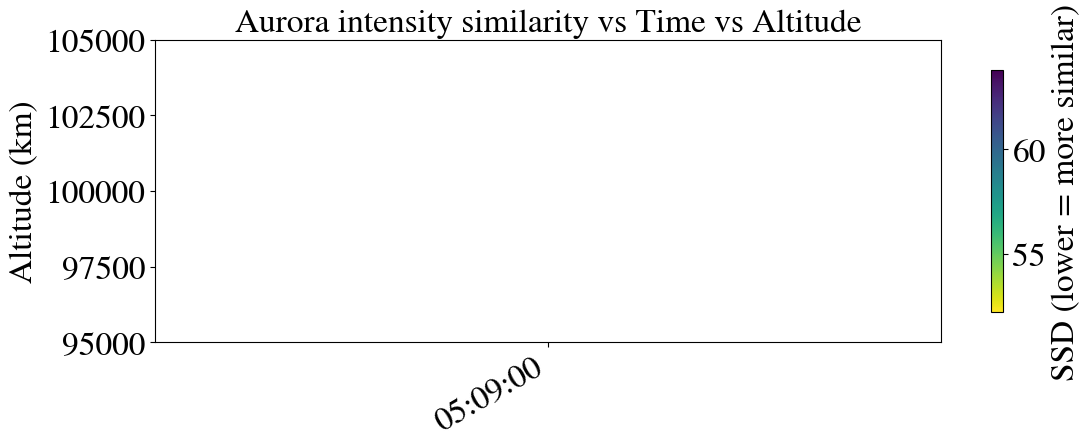

In [9]:
# prepare altitude + time arrays
altitude_arr = list(ssd_correlation_dict.keys())
example_alt = altitude_arr[0]
#time_arr = np.arange(len(correlation_dict[example_alt]))  # assume same length

# computer number of altitudes and number of times from ssd_matrix
n_alts, n_times = ssd_matrix.shape

# generate the time labels for the plot 
t_str_arr = []
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_arr.append(time_obj.strftime("%H:%M:%S"))

# plot the correlation matrix over time and projected altitude 
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    ssd_matrix,
    origin='lower',
    aspect='auto',
    extent=[0, n_times - 1, altitude_arr[0], altitude_arr[-1]],
    cmap='viridis_r'
)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('SSD (lower = more similar)')

ax.set_xticks(np.arange(n_times))
ax.set_xticklabels(t_str_arr, rotation=30, ha='right')
ax.set_ylabel('Altitude (km)')
ax.set_title('Aurora intensity similarity vs Time vs Altitude')

plt.tight_layout()
plt.show()


### SAD

/tmp/ipykernel_47172/3318435507.py:19: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_47172/3318435507.py:19: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(


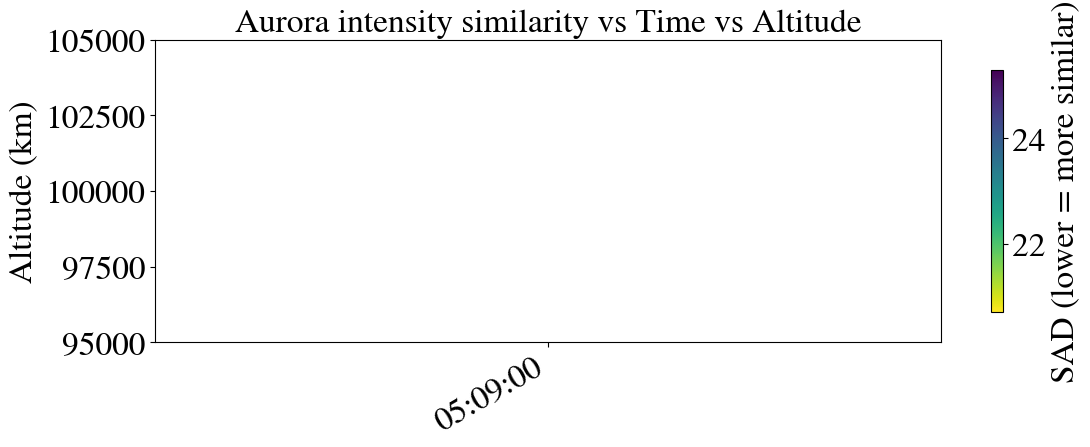

In [10]:
# prepare altitude + time arrays
altitude_arr = list(sad_correlation_dict.keys())
example_alt = altitude_arr[0]
#time_arr = np.arange(len(correlation_dict[example_alt]))  # assume same length

# computer number of altitudes and number of times from sad_matrix
n_alts, n_times = sad_matrix.shape

# generate the time labels for the plot 
t_str_arr = []
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_arr.append(time_obj.strftime("%H:%M:%S"))

# plot the correlation matrix over time and projected altitude 
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    sad_matrix,
    origin='lower',
    aspect='auto',
    extent=[0, n_times - 1, altitude_arr[0], altitude_arr[-1]],
    cmap='viridis_r'
)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('SAD (lower = more similar)')

ax.set_xticks(np.arange(n_times))
ax.set_xticklabels(t_str_arr, rotation=30, ha='right')
ax.set_ylabel('Altitude (km)')
ax.set_title('Aurora intensity similarity vs Time vs Altitude')

plt.tight_layout()
plt.show()


### mean diff

/tmp/ipykernel_47172/3976344394.py:19: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_47172/3976344394.py:19: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(


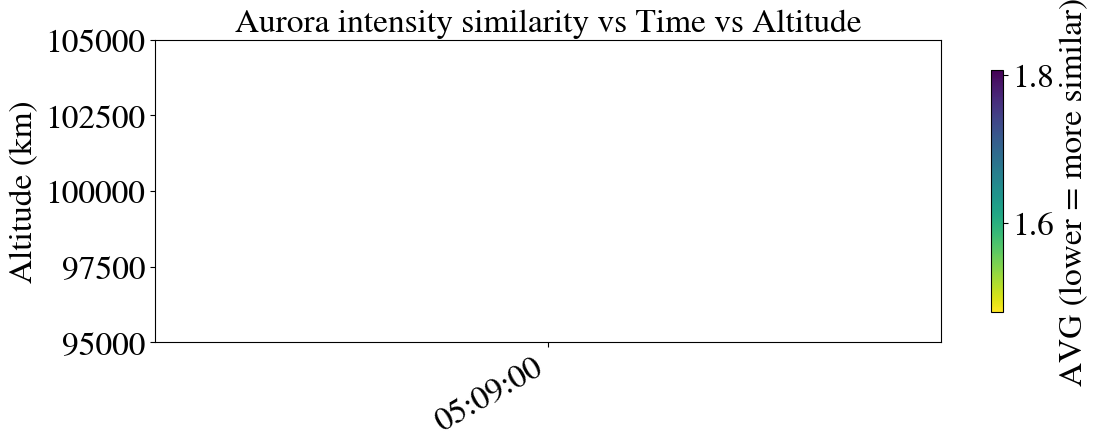

In [11]:
# prepare altitude + time arrays
altitude_arr = list(avg_correlation_dict.keys())
example_alt = altitude_arr[0]
#time_arr = np.arange(len(correlation_dict[example_alt]))  # assume same length

# computer number of altitudes and number of times from avg_matrix
n_alts, n_times = avg_matrix.shape

# generate the time labels for the plot 
t_str_arr = []
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_arr.append(time_obj.strftime("%H:%M:%S"))

# plot the correlation matrix over time and projected altitude 
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    avg_matrix,
    origin='lower',
    aspect='auto',
    extent=[0, n_times - 1, altitude_arr[0], altitude_arr[-1]],
    cmap='viridis_r'
)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('AVG (lower = more similar)')

ax.set_xticks(np.arange(n_times))
ax.set_xticklabels(t_str_arr, rotation=30, ha='right')
ax.set_ylabel('Altitude (km)')
ax.set_title('Aurora intensity similarity vs Time vs Altitude')

plt.tight_layout()
plt.show()


### med diff

/tmp/ipykernel_47172/496359477.py:19: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_47172/496359477.py:19: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(


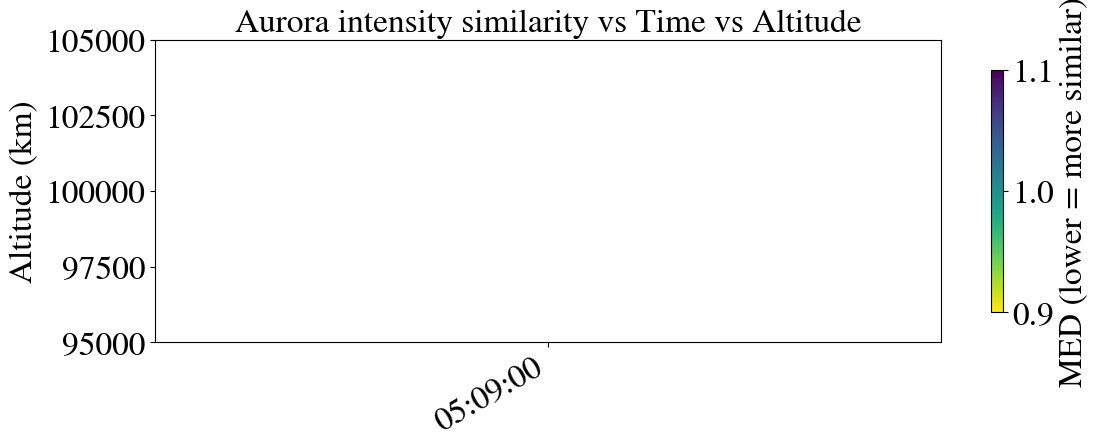

In [12]:
# prepare altitude + time arrays
altitude_arr = list(med_correlation_dict.keys())
example_alt = altitude_arr[0]
#time_arr = np.arange(len(correlation_dict[example_alt]))  # assume same length

# computer number of altitudes and number of times from med_matrix
n_alts, n_times = med_matrix.shape

# generate the time labels for the plot 
t_str_arr = []
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_arr.append(time_obj.strftime("%H:%M:%S"))

# plot the correlation matrix over time and projected altitude 
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    med_matrix,
    origin='lower',
    aspect='auto',
    extent=[0, n_times - 1, altitude_arr[0], altitude_arr[-1]],
    cmap='viridis_r'
)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('MED (lower = more similar)')

ax.set_xticks(np.arange(n_times))
ax.set_xticklabels(t_str_arr, rotation=30, ha='right')
ax.set_ylabel('Altitude (km)')
ax.set_title('Aurora intensity similarity vs Time vs Altitude')

plt.tight_layout()
plt.show()


In [13]:
med_matrix

array([[1.]])

In [14]:
avg_matrix

array([[1.64285714]])

In [15]:
diff_matrix[2]

IndexError: index 2 is out of bounds for axis 0 with size 1